This is a dummy dataset obtained generated from ChatGPT.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
sns.set_theme(context="notebook", style="white", palette='deep')

In [31]:
df = pd.read_csv("../../datasets/08_manufacturing/manufacturing_kinetics_dataset.csv")

# **EDA**

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   batch_id                7500 non-null   int64  
 1   timestamp               7500 non-null   object 
 2   machine_id              7500 non-null   object 
 3   temperature_C           7500 non-null   float64
 4   pressure_bar            7500 non-null   float64
 5   raw_material_kg         7500 non-null   float64
 6   batch_size_kg           7500 non-null   float64
 7   reaction_rate_constant  7500 non-null   float64
 8   reaction_time_min       7500 non-null   float64
 9   machine_runtime_min     7500 non-null   float64
 10  downtime_min            7500 non-null   float64
 11  cycle_time_min          7500 non-null   float64
 12  conversion_percent      7500 non-null   float64
 13  production_kg           7500 non-null   float64
 14  defective_kg            7500 non-null   

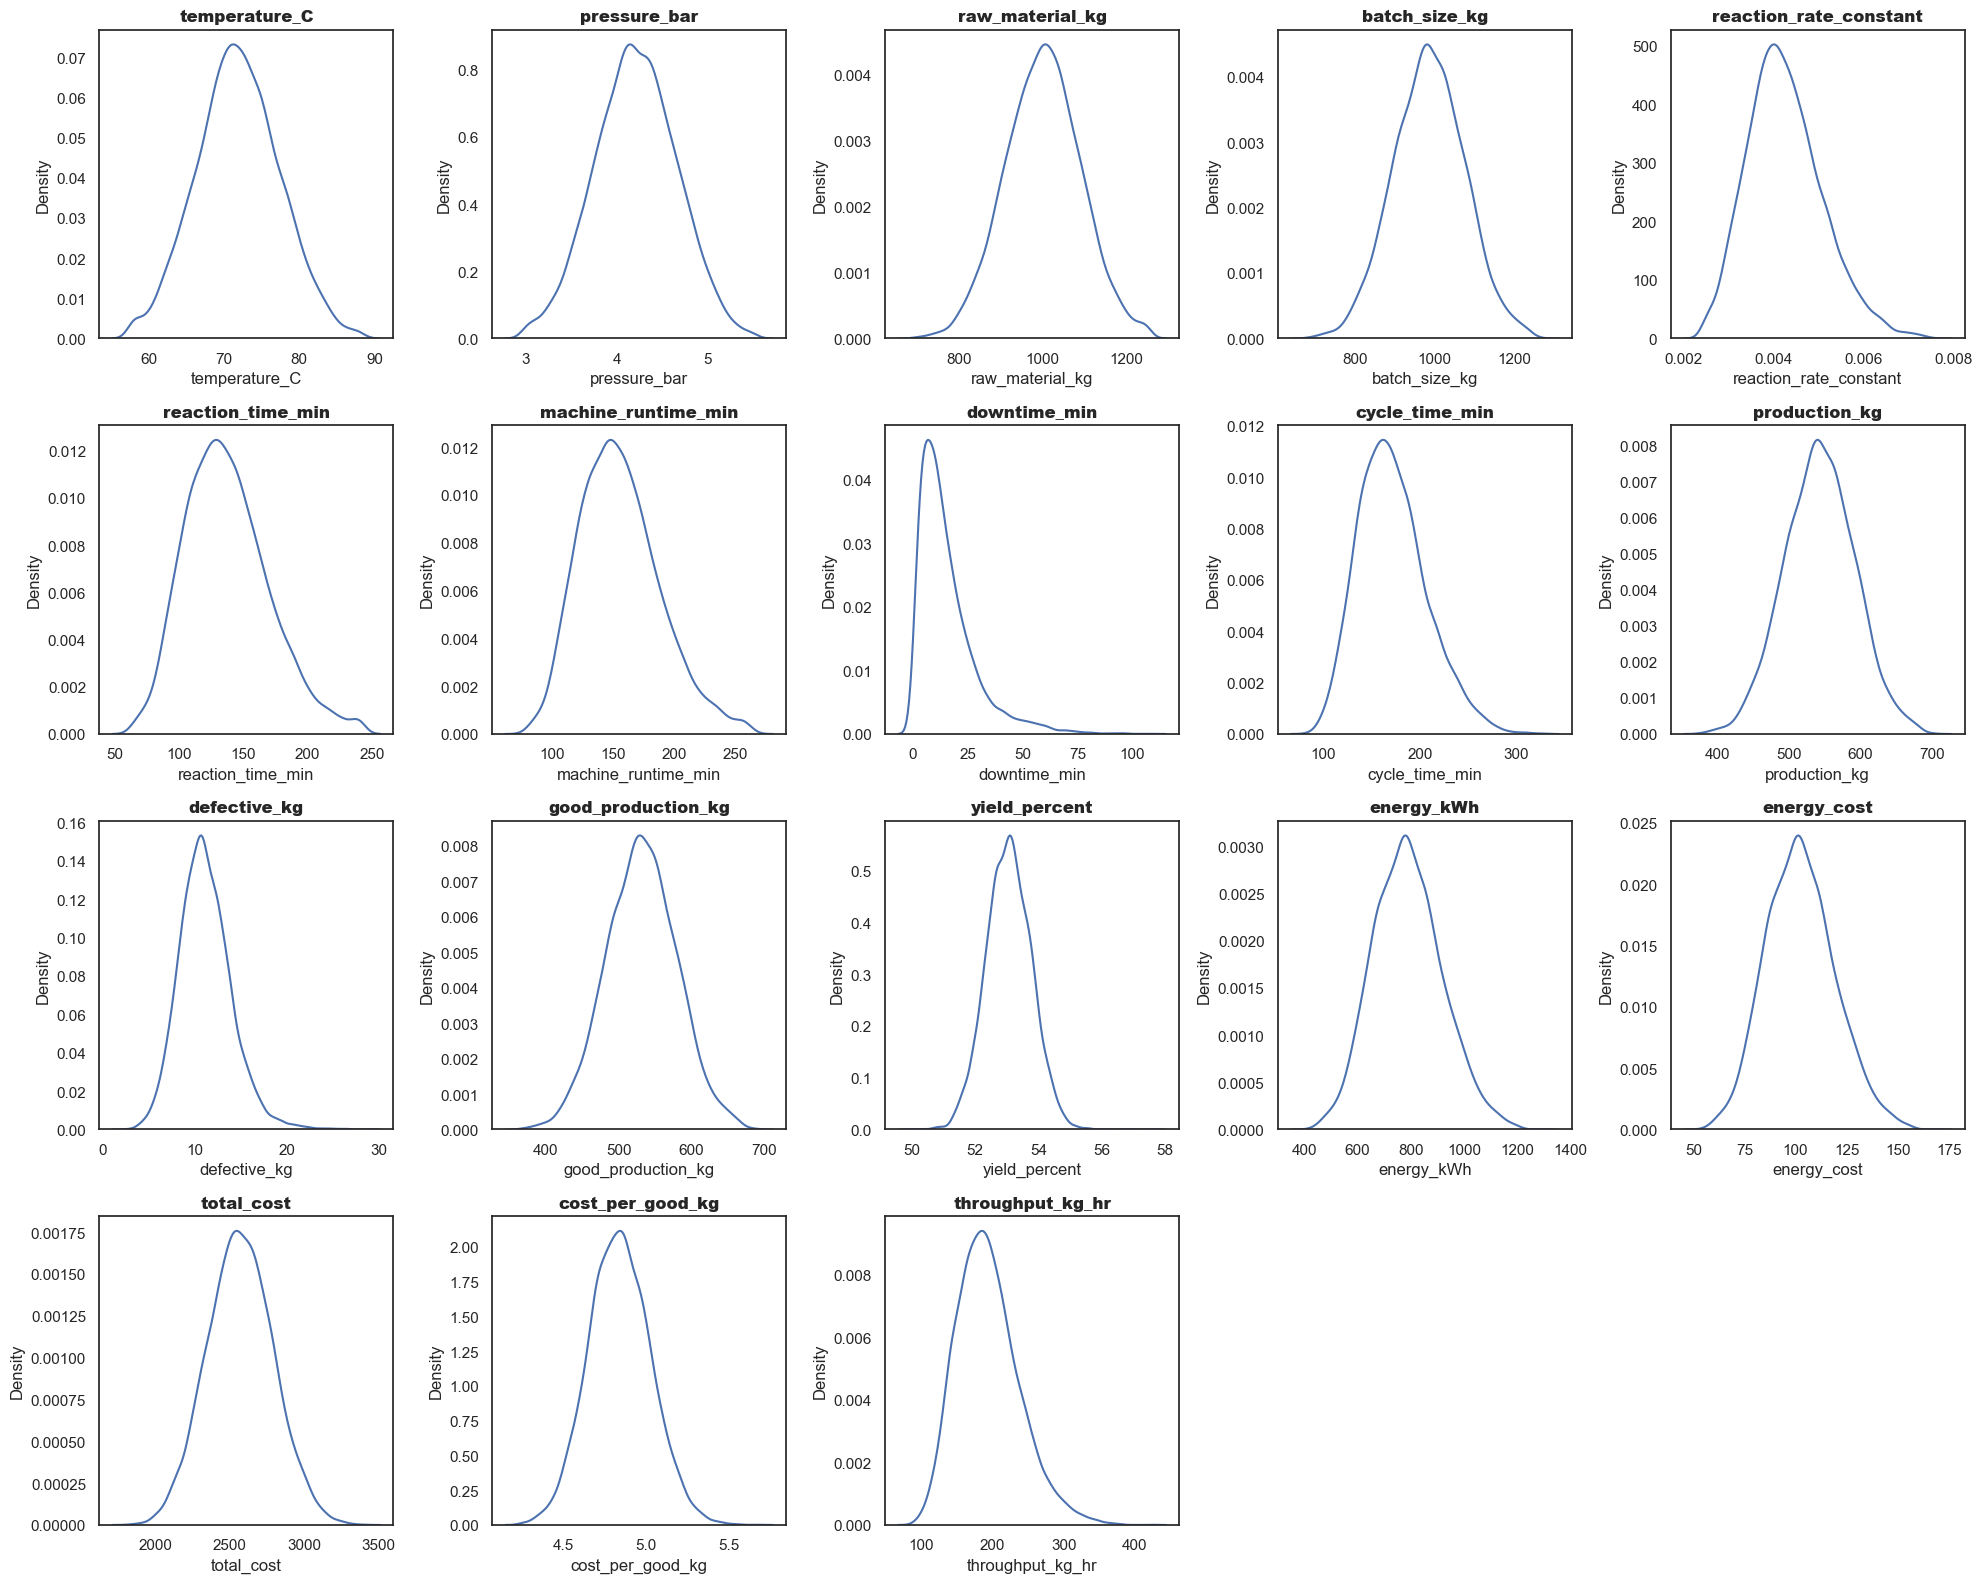

In [33]:
num_cols = df.drop(columns=["batch_id", "conversion_percent"]).select_dtypes(include="number").columns

ncols = 5
nrows = (len(num_cols) + ncols - 1) // ncols # (n + k - 1) // k

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(20, 4 * nrows)
)

axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, ax=ax)
    ax.set_title(col, fontweight=1000)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)


plt.tight_layout()
plt.show()

# **Formatting and cleaning the data**

In [34]:
machines = {}

for machine_id in df['machine_id'].unique():
    machines[machine_id] = df[df['machine_id'] == machine_id].copy().reset_index(drop=True)
    machines[machine_id]["ln_k"] = np.log(machines[machine_id]["reaction_rate_constant"])
    machines[machine_id]["temperature_K"] = machines[machine_id]["temperature_C"] + 273.15
    machines[machine_id]["1/T"] = 1/machines[machine_id]["temperature_K"]
    machines[machine_id].sort_values("timestamp")
    machines[machine_id]["month"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.month_name()
    machines[machine_id]["day"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.day
    machines[machine_id]["year"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.year
    machines[machine_id]["hour"] = pd.to_datetime(machines[machine_id]["timestamp"]).dt.hour
    machines[machine_id].drop(columns=["timestamp", "batch_id"])

In [39]:
df.groupby("machine_id")["total_cost"].aggregate(["mean", "std"])

,mean,std
machine_id,,
M01,2571.756830,224.753648
M02,2569.050940,224.556183
M03,2565.423121,221.639676
M04,2572.166157,223.078437
M05,2577.012106,218.972995


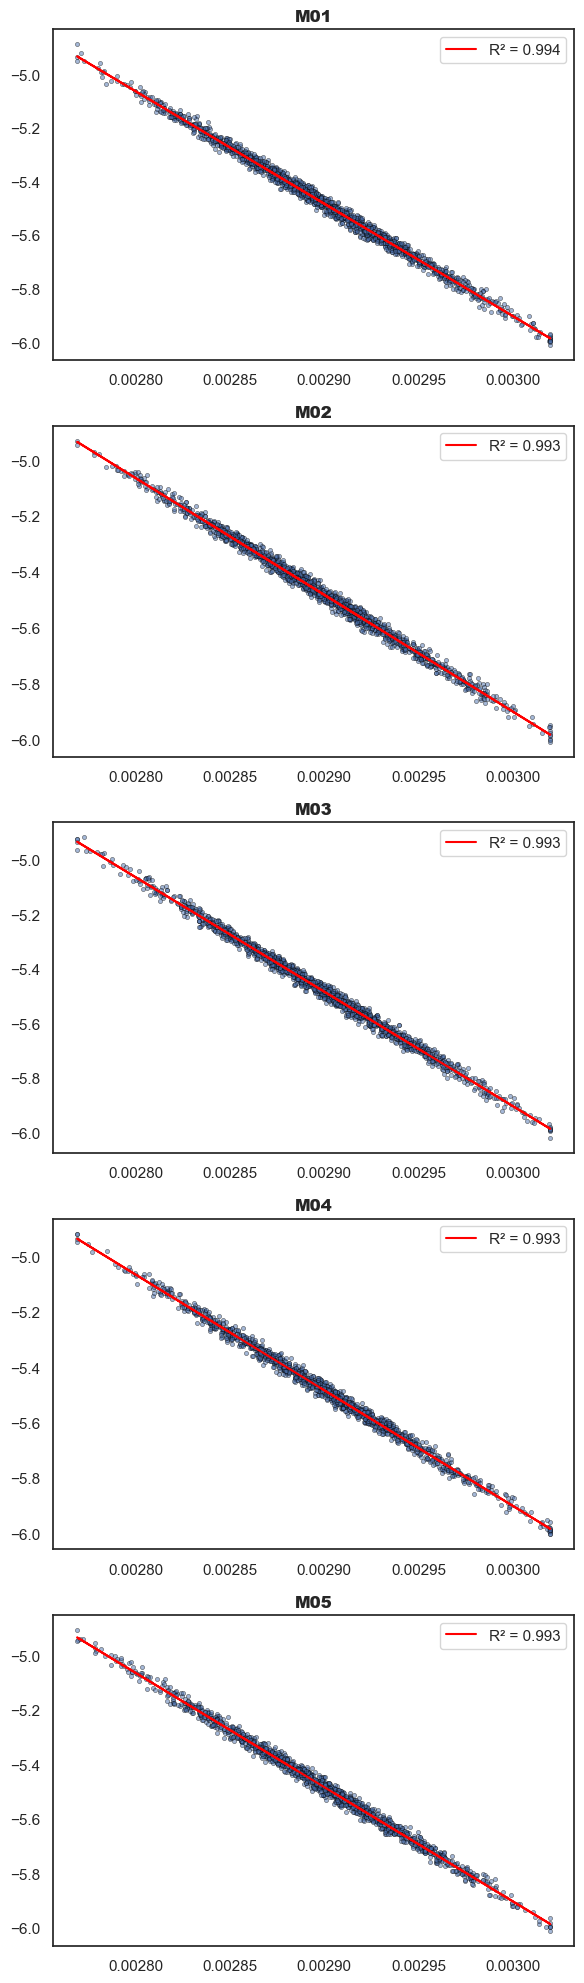

In [36]:
from scipy.stats import linregress
nrows = len(machines)

fig, axes = plt.subplots(nrows=nrows, figsize=(6,4 * nrows))

for ax, machine in zip(axes, sorted(machines)):
    graph = machines[machine]
    x = graph["1/T"]
    y = graph["ln_k"]
    r = linregress(x,y)
    ax.scatter(x,y, marker=".", edgecolors="black", linewidths=0.5, alpha=0.5)
    ax.plot(x, r.intercept + r.slope * x, color="red", label=f"R² = {r.rvalue ** 2:.3f}")
    ax.set_title(machine, fontweight=1000)
    ax.legend()

plt.tight_layout()

# Why not use seaborn for this?
# from scipy.stats import linregress
# nrows = len(machines)

# fig, axes = plt.subplots(nrows=nrows, figsize=(6,4 * nrows))

# for ax, machine in zip(axes, sorted(machines)):
#     df = machines[machine]
#     r = linregress(df["1/T"], df["ln_k"])
#     sns.scatterplot(data=df, x="1/T", y="ln_k", ax=ax)
#     sns.lineplot(x=df["1/T"], y=r.intercept + r.slope * df["1/T"], ax=ax, label=f"R² = {r.rvalue**2:.3f}", color="red")
#     ax.set_title(machine, fontweight=1000)

# This takes 25 seconds to run.

# Highest Throughput machines 

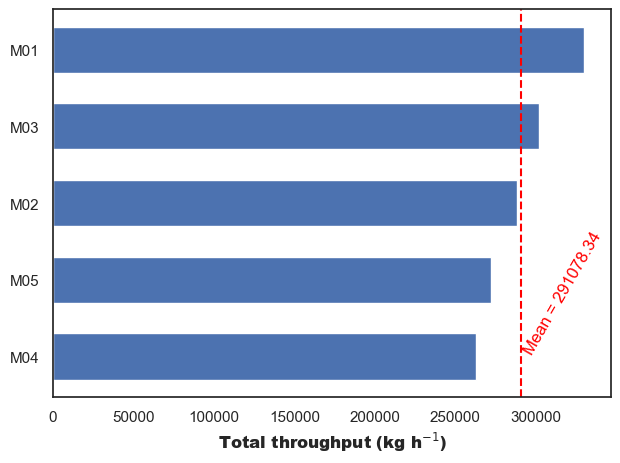

In [ ]:
highest_throughput = df.groupby("machine_id")["throughput_kg_hr"].agg("sum").sort_values(ascending=True)

plt.barh(highest_throughput.index, highest_throughput.values, height=0.6)
plt.xlabel("Total throughput (kg h$^{-1}$)", fontweight=800)
plt.axvline(highest_throughput.mean(), linestyle="--", color="red")
plt.text(highest_throughput.mean(), 0, f"Mean = {highest_throughput.mean():.2f}", va="bottom", color="red", rotation=60)
plt.tight_layout()